# Phase 2: Clustering & UMAP Visualization

Cluster the 512-d Marengo video embeddings using **KMeans**, detect outliers by cosine centroid distance, and reduce to 2D with **UMAP** for visualization.

**Pipeline:** Load embeddings &rarr; L2 normalize &rarr; KMeans cluster &rarr; Centroid distances &rarr; Outlier detection &rarr; UMAP 2D &rarr; Scatter plot

**Key specs:**
- Clustering: `sklearn.cluster.KMeans` with adaptive k
- Distance metric: cosine (via L2-normalized euclidean)
- Outlier threshold: mean + 2&sigma;
- Dimensionality reduction: `umap.UMAP` with cosine metric

## 1. Setup & Imports

In [1]:
import os
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import fiftyone as fo
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
from sklearn.preprocessing import normalize
import umap

print("All imports loaded")

/Users/rishimule/Desktop/GitHub/video-content-gap-analyzer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports loaded


## 2. Load Dataset & Extract Embeddings

The dataset should already have 512-d Marengo embeddings from Phase 1.

In [2]:
dataset = fo.load_dataset("Voxel51/Safe_and_Unsafe_Behaviours")

# Extract embeddings from samples that have them
samples_list = []
embeddings_list = []
filenames = []
gt_labels = []

for sample in dataset:
    try:
        emb = sample["embedding"]
    except (KeyError, AttributeError):
        continue
    if emb is not None:
        samples_list.append(sample)
        embeddings_list.append(emb)
        filenames.append(os.path.basename(sample.filepath))
        label = sample.ground_truth.label if sample.ground_truth else "unknown"
        gt_labels.append(label)

embeddings = np.array(embeddings_list)
n_samples = len(embeddings)

print(f"Dataset: {dataset.name} ({len(dataset)} total)")
print(f"Embedding matrix shape: {embeddings.shape}")
print(f"Mean norm: {np.linalg.norm(embeddings, axis=1).mean():.4f}")
print(f"Samples with embeddings: {n_samples} / {len(dataset)}")
print(f"\nGround truth categories:")
for label, count in Counter(gt_labels).most_common():
    print(f"  {label}: {count}")

Dataset: Voxel51/Safe_and_Unsafe_Behaviours (200 total)
Embedding matrix shape: (30, 512)
Mean norm: 0.9994
Samples with embeddings: 30 / 200

Ground truth categories:
  Safe Walkway Violation: 15
  Unauthorized Intervention: 15


## 3. Embedding Similarity Recap

Quick check: how similar are these embeddings? High similarity means clustering will find subtle structure.

In [3]:
sim_matrix = cosine_similarity(embeddings)
mask = ~np.eye(n_samples, dtype=bool)
off_diag = sim_matrix[mask]

print(f"Pairwise cosine similarity (off-diagonal):")
print(f"  Min:  {off_diag.min():.4f}")
print(f"  Mean: {off_diag.mean():.4f}")
print(f"  Max:  {off_diag.max():.4f}")
print(f"\nEmbeddings are highly similar — clustering will find subtle structure")

Pairwise cosine similarity (off-diagonal):
  Min:  0.9641
  Mean: 0.9854
  Max:  0.9984

Embeddings are highly similar — clustering will find subtle structure


## 4. Normalize & Cluster

L2-normalize embeddings to the unit sphere so euclidean KMeans approximates spherical k-means (cosine distance). Use ground truth category count as a hint for `n_clusters`.

In [4]:
# L2 normalize
embeddings_norm = normalize(embeddings, norm="l2")
print(f"Mean norm after normalization: {np.linalg.norm(embeddings_norm, axis=1).mean():.4f}")

# Adaptive n_clusters — use ground truth category count as hint
n_gt_categories = len(set(gt_labels))
max_k = max(2, n_samples // 3)
n_clusters = min(n_gt_categories, max_k)
n_clusters = max(2, n_clusters)
print(f"n_clusters = {n_clusters} for {n_samples} samples "
      f"({n_gt_categories} ground truth categories)")

# KMeans
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(embeddings_norm)
centroids_norm = normalize(kmeans.cluster_centers_, norm="l2")

# Evaluate
sil_score = silhouette_score(embeddings_norm, labels, metric="cosine")
print(f"\nSilhouette score (cosine): {sil_score:.4f}")

unique, counts = np.unique(labels, return_counts=True)
print("\nCluster distribution:")
for cid, cnt in zip(unique, counts):
    print(f"  Cluster {cid}: {cnt} samples")

Mean norm after normalization: 1.0000
n_clusters = 2 for 30 samples (2 ground truth categories)

Silhouette score (cosine): 0.3679

Cluster distribution:
  Cluster 0: 14 samples
  Cluster 1: 16 samples


## 5. Centroid Distances & Outlier Detection

Compute the cosine distance from each sample to its assigned cluster centroid. Flag outliers where distance exceeds mean + 2&sigma;.

In [5]:
# Cosine distance from each sample to its cluster centroid
distances = np.array([
    cosine_distances(
        embeddings_norm[i:i+1],
        centroids_norm[labels[i]:labels[i]+1],
    )[0, 0]
    for i in range(n_samples)
])

mean_dist = distances.mean()
std_dist = distances.std()

# Outlier detection
if std_dist > 0:
    threshold = mean_dist + 2 * std_dist
    is_outlier = distances > threshold
else:
    threshold = mean_dist
    is_outlier = np.zeros(n_samples, dtype=bool)

print(f"{'Filename':<16} {'Cluster':>7} {'Distance':>10} {'Outlier':>8}")
print("-" * 45)
for i in range(n_samples):
    print(f"{filenames[i]:<16} {labels[i]:>7} {distances[i]:>10.6f} {'YES' if is_outlier[i] else '':>8}")

print(f"\nMean distance:    {mean_dist:.6f}")
print(f"Std distance:     {std_dist:.6f}")
print(f"Outlier threshold: {threshold:.6f}")
print(f"Outliers flagged:  {is_outlier.sum()}")

Filename         Cluster   Distance  Outlier
---------------------------------------------
0_tr1.mp4              0   0.002690         
0_tr10.mp4             1   0.004421         
0_tr100.mp4            0   0.002224         
0_tr101.mp4            0   0.003255         
0_tr102.mp4            0   0.004040         
0_tr103.mp4            0   0.001377         
0_tr104.mp4            0   0.005911         
0_tr105.mp4            0   0.004297         
0_tr106.mp4            0   0.005335         
0_tr107.mp4            0   0.009566      YES
0_tr108.mp4            1   0.004909         
0_tr109.mp4            0   0.005402         
0_tr11.mp4             1   0.005709         
0_tr110.mp4            1   0.009784      YES
0_tr111.mp4            1   0.008808         
1_tr1.mp4              1   0.003719         
1_tr10.mp4             0   0.003884         
1_tr11.mp4             1   0.006574         
1_tr12.mp4             1   0.009558      YES
1_tr13.mp4             1   0.002269         
1_tr14.mp

## 6. UMAP Reduction to 2D

Project 512-d embeddings to 2D using UMAP with cosine metric for visualization.

In [6]:
n_neighbors = min(5, n_samples - 1)
reducer = umap.UMAP(
    n_components=2,
    metric="cosine",
    n_neighbors=n_neighbors,
    min_dist=0.1,
    random_state=42,
)
coords_2d = reducer.fit_transform(embeddings_norm)

print(f"UMAP output shape: {coords_2d.shape}")
print(f"x range: [{coords_2d[:, 0].min():.4f}, {coords_2d[:, 0].max():.4f}]")
print(f"y range: [{coords_2d[:, 1].min():.4f}, {coords_2d[:, 1].max():.4f}]")

/Users/rishimule/Desktop/GitHub/video-content-gap-analyzer/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (30, 2)
x range: [12.0095, 14.6899]
y range: [-11.7124, 3.1111]


## 7. Visualize Clusters

Scatter plot of the 2D UMAP projection, colored by cluster assignment. Outliers (if any) are circled in red.

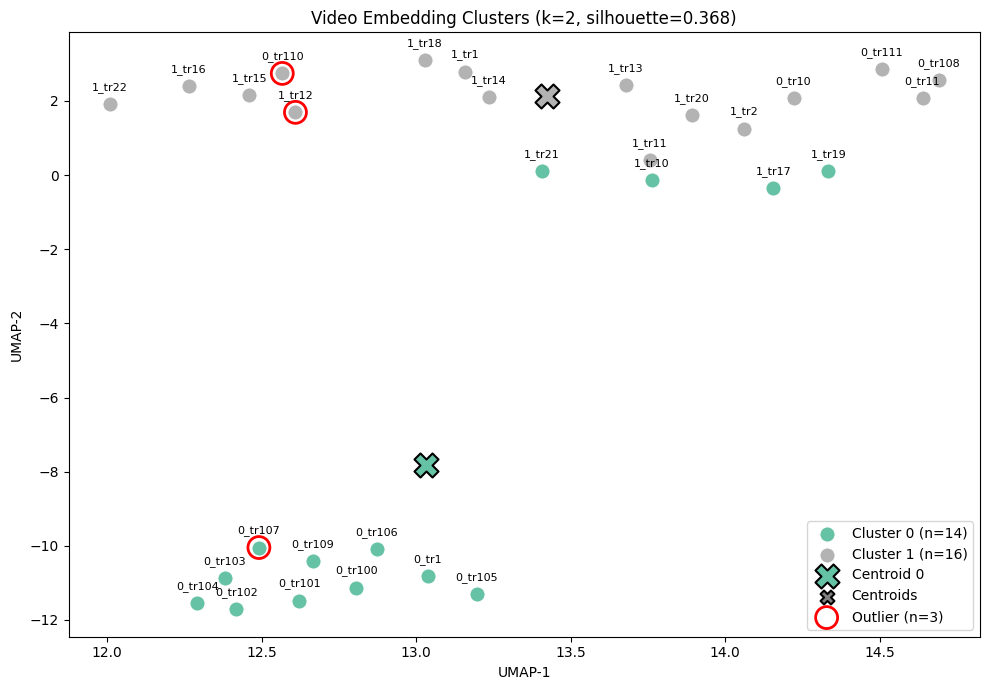

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

# Color by cluster
colors = plt.cm.Set2(np.linspace(0, 1, n_clusters))
for cid in range(n_clusters):
    mask = labels == cid
    ax.scatter(
        coords_2d[mask, 0], coords_2d[mask, 1],
        c=[colors[cid]], label=f"Cluster {cid} (n={mask.sum()})",
        s=120, edgecolors="white", linewidths=0.8, zorder=2,
    )

# Plot centroids (mean of 2D cluster member positions)
for cid in range(n_clusters):
    mask = labels == cid
    cx = coords_2d[mask, 0].mean()
    cy = coords_2d[mask, 1].mean()
    ax.scatter(
        cx, cy, c=[colors[cid]], marker="X", s=300,
        edgecolors="black", linewidths=1.5, zorder=4,
        label=f"Centroid {cid}" if cid == 0 else f"_nolegend_",
    )
    # Only add "Centroids" once to legend
if n_clusters > 0:
    ax.scatter([], [], marker="X", c="gray", s=100,
               edgecolors="black", linewidths=1.5, label="Centroids")

# Mark outliers with red circles
if is_outlier.any():
    ax.scatter(
        coords_2d[is_outlier, 0], coords_2d[is_outlier, 1],
        facecolors="none", edgecolors="red", s=250, linewidths=2,
        label=f"Outlier (n={is_outlier.sum()})", zorder=3,
    )

# Label each point with filename
for i, name in enumerate(filenames):
    ax.annotate(
        name.replace(".mp4", ""),
        (coords_2d[i, 0], coords_2d[i, 1]),
        fontsize=8, ha="center", va="bottom",
        xytext=(0, 8), textcoords="offset points",
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title(f"Video Embedding Clusters (k={n_clusters}, silhouette={sil_score:.3f})")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 8. Store Results in FiftyOne

Write all computed fields back to the dataset samples.

In [8]:
for i, sample in enumerate(samples_list):
    sample["cluster_id"] = int(labels[i])
    sample["centroid_distance"] = float(distances[i])
    sample["is_outlier"] = bool(is_outlier[i])
    sample["umap_x"] = float(coords_2d[i, 0])
    sample["umap_y"] = float(coords_2d[i, 1])
    sample.save()

dataset.save()
print(f"All {n_samples} samples updated with clustering fields")

All 30 samples updated with clustering fields


## 9. Summary

In [9]:
print("=" * 50)
print("CLUSTERING SUMMARY")
print("=" * 50)
print(f"Samples clustered:  {n_samples}")
print(f"Number of clusters: {n_clusters}")
print(f"Silhouette score:   {sil_score:.4f} (cosine)")
print()
for cid, cnt in zip(unique, counts):
    print(f"  Cluster {cid}: {cnt} samples")
print()
print(f"Centroid distances — mean: {mean_dist:.6f}, std: {std_dist:.6f}")
print(f"Outlier threshold:  {threshold:.6f}")
print(f"Outliers flagged:   {is_outlier.sum()}")
print()
print(f"UMAP 2D — x: [{coords_2d[:, 0].min():.2f}, {coords_2d[:, 0].max():.2f}], "
      f"y: [{coords_2d[:, 1].min():.2f}, {coords_2d[:, 1].max():.2f}]")
print()

# Sanity check
all_ok = True
for sample in samples_list:
    for field in ["cluster_id", "centroid_distance", "is_outlier", "umap_x", "umap_y"]:
        if sample[field] is None:
            print(f"FAIL: {os.path.basename(sample.filepath)} missing {field}")
            all_ok = False
if all_ok:
    print("Sanity check: all fields written OK")

CLUSTERING SUMMARY
Samples clustered:  30
Number of clusters: 2
Silhouette score:   0.3679 (cosine)

  Cluster 0: 14 samples
  Cluster 1: 16 samples

Centroid distances — mean: 0.005165, std: 0.002184
Outlier threshold:  0.009532
Outliers flagged:   3

UMAP 2D — x: [12.01, 14.69], y: [-11.71, 3.11]

Sanity check: all fields written OK


## 10. Ground Truth Validation

Compare cluster assignments to actual ground truth labels using Adjusted Rand Index (ARI). ARI = 1.0 means perfect alignment, 0.0 means random, negative means anti-correlated.

In [10]:
ari = adjusted_rand_score(gt_labels, labels)
print(f"Adjusted Rand Index: {ari:.4f}")
if ari > 0.5:
    print("-> Good: clusters align well with ground truth categories")
elif ari > 0.1:
    print("-> Moderate: partial alignment with ground truth")
else:
    print("-> Low: clusters do not match ground truth categories")

# Cross-tabulation: what ground truth labels are in each cluster?
print("\nCluster vs Ground Truth:")
for cid in range(n_clusters):
    cluster_labels = [gt_labels[i] for i in range(n_samples) if labels[i] == cid]
    dist = Counter(cluster_labels)
    parts = ", ".join(f"{lbl}: {cnt}" for lbl, cnt in dist.most_common())
    print(f"  Cluster {cid}: {parts}")

Adjusted Rand Index: 0.1301
-> Moderate: partial alignment with ground truth

Cluster vs Ground Truth:
  Cluster 0: Safe Walkway Violation: 10, Unauthorized Intervention: 4
  Cluster 1: Unauthorized Intervention: 11, Safe Walkway Violation: 5


## 11. Launch FiftyOne App

Browse the dataset with cluster assignments visible in the FiftyOne App.

In [11]:
session = fo.launch_app(dataset)


Could not connect session, trying again in 10 seconds



RuntimeError: Client is not connected